# 🧪 01 – Data Preprocessing
**Proyek:** AI-Based Pharmaceutical Data Selection & Monitoring System  
**Tim:** PJK-GM016 | Pijak × IBM SkillsBuild  
**Minggu:** 2 – Data Cleaning, Preprocessing & Feature Engineering

---
### Alur Notebook
| Langkah | Deskripsi |
|---------|-----------|
| 1 | Load data CSV mentah |
| 2 | Hapus duplikat |
| 3 | Filter baris valid |
| 4 | Konversi kolom numerik |
| 5 | Analisis missing values |
| 6 | Imputasi missing values |
| 7 | Parsing kadar air |
| 8 | Parsing tanggal |
| 9 | Feature engineering |
| 10 | Ringkasan statistik |
| 11 | Simpan output bersih |


## Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="Set2", font_scale=1.1)
print("Library berhasil diimport")
print(f"   pandas  : {pd.__version__}")
print(f"   numpy   : {np.__version__}")

Library berhasil diimport
   pandas  : 2.3.3
   numpy   : 2.3.5


## Step 1 – Load Data

In [3]:
INPUT_CSV = "./rekap_produksi_granulasi_raw (1).csv"
OUTPUT_CSV = "rekap_produksi_clean.csv"

df = pd.read_csv(INPUT_CSV)
print(f"Shape awal   : {df.shape}")
print(f"Jumlah kolom : {df.shape[1]}")
print(f"Jumlah baris : {df.shape[0]}")
df.head(3)

Shape awal   : (718, 51)
Jumlah kolom : 51
Jumlah baris : 718


,Status,Material_Description,Material_Code,Code_Material,RK,Tahun,Created_On_SAP,No_Order,Batch,Batch_Ke,...,Tgl_Kemul,Mesin_Sealing,Sealing,Forming,Hasil_Blister_Reject,Tablet_Rusak_Kg,Sampah_Cacahan_Kg,Blister_Kosong_Kg,Waste_Sedotan_Kg,Waste_Sample_IPC_Kg
0,s,APC PLUS TABLET/20E NF NG,APCP,F1791,5.0,2024.0,29.04.2024,300021182.0,051364 1,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,s,APC PLUS TABLET/20E NF NG,APCP,F1791,5.0,2024.0,29.04.2024,300021183.0,051364 2,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,s,APC PLUS TABLET/20E NF NG,APCP,F1791,5.0,2024.0,29.04.2024,300021184.0,051364 3,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Step 2 – Hapus Duplikasi

In [4]:
before = len(df)
df = df.drop_duplicates()
after  = len(df)
print(f"Baris sebelum  : {before}")
print(f"Baris setelah  : {after}")
print(f"Duplikat dihapus: {before - after}")

Baris sebelum  : 718
Baris setelah  : 667
Duplikat dihapus: 51


## Step 3 – Filter Baris Valid (ada Material)

In [5]:
before = len(df)
df = df.dropna(subset=['Material_Description', 'Material_Code'])
after  = len(df)
print(f"Baris dihapus (tidak ada material): {before - after}")
print(f"Baris valid: {after}")
df['Material_Description'].value_counts()

Baris dihapus (tidak ada material): 5
Baris valid: 662


Material_Description
BODREX EXTRA KAPLET/4'S                212
NEO RHEUMACYL TABLET NP/24 X 20        158
BODREX MIGRA / 4 KAPLET                107
BODREX FLU & BATUK PE/4'S               89
FORPAIN KAPLET/20E NF                   27
SUDREX EXTRA/TAB 2X10'S FBX             27
APC PLUS TABLET/20E NF NG               19
BODREX FLU & BATUK BERDAHAK PE/4'S      14
BODREX FLU/KAP 4’S BLS                   4
SUDREX COLD & COUGH/KAP 10'S SLEEVE      3
BODREX PILEK ALERGI/KAP 4'S BLS          1
BODREX PILEK/KAP 4'S BLS                 1
Name: count, dtype: int64

## Step 4 – Konversi Kolom Numerik

In [6]:
NUMERIC_COLS = [
    'GB_Yield_Kg_L1', 'GB_Yield_Kg_L2',
    'GK_Yield_Kg_L1', 'GK_Yield_Kg_L2',
    'Cetak_Yield_Kg', 'Cetak_Pct_Teoritis',
    'Kemas_Yield_Blister', 'Kemas_Pct_Teoritis',
    'Tablet_Rusak_Kg', 'Sampah_Cacahan_Kg',
    'Blister_Kosong_Kg', 'Waste_Sedotan_Kg',
    'Waste_Sample_IPC_Kg', 'Kemul_Tambahan'
]

for col in NUMERIC_COLS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print("Konversi selesai")
df[NUMERIC_COLS].dtypes

Konversi selesai


GB_Yield_Kg_L1         float64
GB_Yield_Kg_L2         float64
GK_Yield_Kg_L1         float64
GK_Yield_Kg_L2         float64
Cetak_Yield_Kg         float64
Cetak_Pct_Teoritis     float64
Kemas_Yield_Blister    float64
Kemas_Pct_Teoritis     float64
Tablet_Rusak_Kg        float64
Sampah_Cacahan_Kg      float64
Blister_Kosong_Kg      float64
Waste_Sedotan_Kg       float64
Waste_Sample_IPC_Kg    float64
Kemul_Tambahan         float64
dtype: object

## Step 5 – Analisis Missing Values

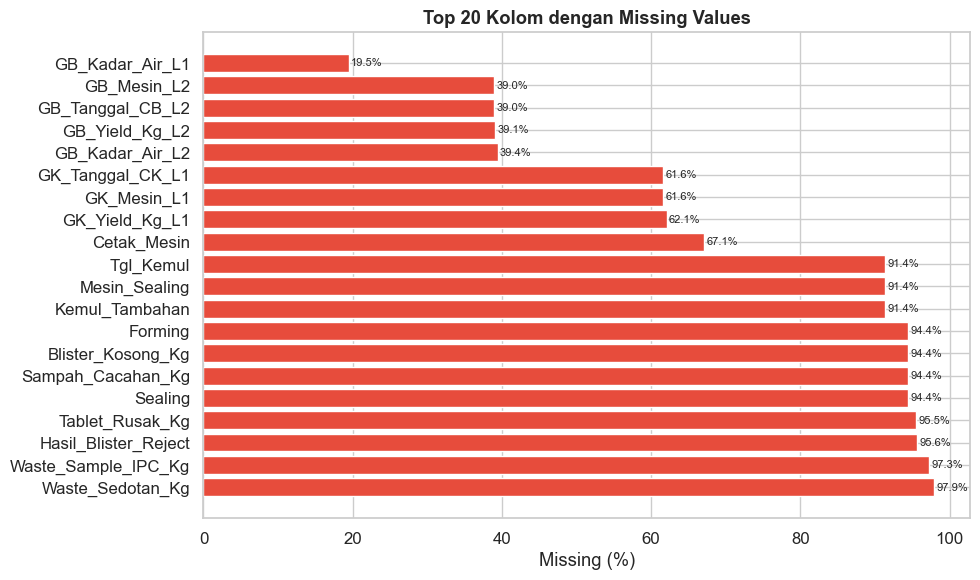

,Missing Count,Missing %
Waste_Sedotan_Kg,648,97.89
Waste_Sample_IPC_Kg,644,97.28
Hasil_Blister_Reject,633,95.62
Tablet_Rusak_Kg,632,95.47
Sealing,625,94.41
Sampah_Cacahan_Kg,625,94.41
Blister_Kosong_Kg,625,94.41
Forming,625,94.41
Kemul_Tambahan,605,91.39
Mesin_Sealing,605,91.39


In [7]:
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
mv_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
mv_df = mv_df[mv_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

# Visualisasi
fig, ax = plt.subplots(figsize=(10, 6))
top_mv = mv_df.head(20)
bars = ax.barh(top_mv.index, top_mv['Missing %'], color='#e74c3c', edgecolor='white')
ax.set_xlabel("Missing (%)")
ax.set_title("Top 20 Kolom dengan Missing Values", fontweight='bold')
for bar in bars:
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.1f}%', va='center', fontsize=8)
plt.tight_layout()
plt.show()

mv_df

## Step 6 – Imputasi Missing Values

In [9]:
# Kolom waste / reject → isi 0 (tidak ada waste = 0)
waste_cols = [
    'Tablet_Rusak_Kg', 'Sampah_Cacahan_Kg', 'Blister_Kosong_Kg',
    'Waste_Sedotan_Kg', 'Waste_Sample_IPC_Kg', 'Kemul_Tambahan',
    'Hasil_Blister_Reject', 'Sealing', 'Forming'
]
for col in waste_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# Kolom yield → isi dengan median per material
yield_cols = [
    'GB_Yield_Kg_L1', 'GB_Yield_Kg_L2',
    'GK_Yield_Kg_L1', 'GK_Yield_Kg_L2',
    'Cetak_Yield_Kg', 'Kemas_Yield_Blister'
]
for col in yield_cols:
    if col in df.columns:
        df[col] = df.groupby('Material_Code')[col].transform(
            lambda x: x.fillna(x.median())
        )

# Kolom % teoritis → isi dengan median per material
pct_cols = ['Cetak_Pct_Teoritis', 'Kemas_Pct_Teoritis']
for col in pct_cols:
    if col in df.columns:
        df[col] = df.groupby('Material_Code')[col].transform(
            lambda x: x.fillna(x.median())
        )

remaining_mv = df.isnull().sum()
remaining_mv = remaining_mv[remaining_mv > 0]
print("Missing values tersisa:")
print(remaining_mv if len(remaining_mv) else "Tidak ada missing value di kolom kunci")

Missing values tersisa:
GB_Mesin_L1             2
GB_Mesin_L2           258
GB_Yield_Kg_L2        258
GB_Tanggal_CB_L1        2
GB_Tanggal_CB_L2      258
GB_Kadar_Air_L1       129
GB_Kadar_Air_L2       261
GB_Keterangan           5
GK_Mesin_L1           408
GK_Mesin_L2             5
GK_Yield_Kg_L1        411
GK_Tanggal_CK_L1      408
GK_Tanggal_CK_L2        5
GK_Keterangan           4
Cetak_Mesin           444
Cetak_Tgl_Mulai        14
Cetak_Tgl_Selesai      16
Cetak_Pct_Teoritis      2
Cetak_Keterangan       13
Cetak_Total            16
Kemas_Mesin            26
Kemas_Tgl_Mulai        26
Kemas_Tgl_Selesai      34
Kemas_Pct_Teoritis      2
Kemas_Keterangan       25
Kemas_Total            29
Tgl_Kemul             605
Mesin_Sealing         605
dtype: int64


## Step 7 – Parsing Kadar Air
> Format asli: `'5,50/5,46/5,52'` → diambil rata-rata

In [10]:
def parse_kadar_air(val):
    """Ekstrak rata-rata dari string format '5.40/5.49/5.59'."""
    if pd.isna(val):
        return np.nan
    val = str(val).replace(',', '.').replace('H', '').strip()
    parts = val.split('/')
    nums = []
    for p in parts:
        try:
            nums.append(float(p.strip()))
        except Exception:
            pass
    return np.mean(nums) if nums else np.nan

if 'GB_Kadar_Air_L1' in df.columns:
    df['GB_Kadar_Air_L1_num'] = df['GB_Kadar_Air_L1'].apply(parse_kadar_air)

if 'GB_Kadar_Air_L2' in df.columns:
    df['GB_Kadar_Air_L2_num'] = df['GB_Kadar_Air_L2'].apply(parse_kadar_air)

# Preview
sample = df[['GB_Kadar_Air_L1', 'GB_Kadar_Air_L1_num']].dropna()
print("Contoh hasil parsing kadar air:")
sample.head(8)

Contoh hasil parsing kadar air:


,GB_Kadar_Air_L1,GB_Kadar_Air_L1_num
0,"5,50/5,46/5,52",5.493333
1,"5,35/5,45/5,47",5.423333
2,"5,39/5,60/5,56",5.516667
4,"5,44/5,52/5,54",5.500000
5,"5,41/5,43/5,58",5.473333
6,"5,39/5,45/5,10",5.313333
7,"5,48/5,57/5,48",5.510000
8,"5,40/5,49/5,59",5.493333


## Step 8 – Konversi Kolom Tanggal

In [11]:
date_cols = [
    'GB_Tanggal_CB_L1', 'GB_Tanggal_CB_L2',
    'GK_Tanggal_CK_L1', 'GK_Tanggal_CK_L2',
    'Cetak_Tgl_Mulai', 'Cetak_Tgl_Selesai',
    'Kemas_Tgl_Mulai', 'Kemas_Tgl_Selesai'
]

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

print("Kolom tanggal berhasil dikonversi")
df[[c for c in date_cols if c in df.columns]].dtypes

Kolom tanggal berhasil dikonversi


GB_Tanggal_CB_L1     datetime64[ns]
GB_Tanggal_CB_L2     datetime64[ns]
GK_Tanggal_CK_L1     datetime64[ns]
GK_Tanggal_CK_L2     datetime64[ns]
Cetak_Tgl_Mulai      datetime64[ns]
Cetak_Tgl_Selesai    datetime64[ns]
Kemas_Tgl_Mulai      datetime64[ns]
Kemas_Tgl_Selesai    datetime64[ns]
dtype: object

## Step 9 – Feature Engineering
> Membuat fitur-fitur baru yang relevan untuk model AI

In [12]:
# 9a. Total Yield Granulasi Basah
df['GB_Yield_Total'] = df['GB_Yield_Kg_L1'].fillna(0) + df['GB_Yield_Kg_L2'].fillna(0)

# 9b. Total Yield Granulasi Kering
df['GK_Yield_Total'] = df['GK_Yield_Kg_L1'].fillna(0) + df['GK_Yield_Kg_L2'].fillna(0)

# 9c. Rasio efisiensi pengeringan (GK/GB)
df['Rasio_GK_GB'] = np.where(
    df['GB_Yield_Total'] > 0,
    df['GK_Yield_Total'] / df['GB_Yield_Total'],
    np.nan
)

# 9d. Total waste (semua sumber)
df['Total_Waste_Kg'] = (
    df['Tablet_Rusak_Kg'].fillna(0) +
    df['Sampah_Cacahan_Kg'].fillna(0) +
    df['Blister_Kosong_Kg'].fillna(0) +
    df['Waste_Sedotan_Kg'].fillna(0) +
    df['Waste_Sample_IPC_Kg'].fillna(0)
)

# 9e. Label defect (threshold % teoritis < 90%)
THRESHOLD = 0.90
df['Defect_Cetak']   = (df['Cetak_Pct_Teoritis']  < THRESHOLD).astype(int)
df['Defect_Kemas']   = (df['Kemas_Pct_Teoritis']  < THRESHOLD).astype(int)
df['Defect_Overall'] = ((df['Defect_Cetak'] == 1) | (df['Defect_Kemas'] == 1)).astype(int)

# 9f. Durasi proses (hari)
if 'Cetak_Tgl_Mulai' in df.columns and 'Cetak_Tgl_Selesai' in df.columns:
    df['Cetak_Durasi_Hari'] = (df['Cetak_Tgl_Selesai'] - df['Cetak_Tgl_Mulai']).dt.days.clip(lower=0)

if 'Kemas_Tgl_Mulai' in df.columns and 'Kemas_Tgl_Selesai' in df.columns:
    df['Kemas_Durasi_Hari'] = (df['Kemas_Tgl_Selesai'] - df['Kemas_Tgl_Mulai']).dt.days.clip(lower=0)

# 9g. Bulan & tahun produksi
if 'Cetak_Tgl_Mulai' in df.columns:
    df['Bulan_Produksi'] = df['Cetak_Tgl_Mulai'].dt.month
    df['Tahun_Produksi'] = df['Cetak_Tgl_Mulai'].dt.year

# 9h. Rata-rata kadar air
if 'GB_Kadar_Air_L1_num' in df.columns:
    df['GB_Kadar_Air_Mean'] = df[['GB_Kadar_Air_L1_num', 'GB_Kadar_Air_L2_num']].mean(axis=1, skipna=True)

new_feats = [
    'GB_Yield_Total', 'GK_Yield_Total', 'Rasio_GK_GB', 'Total_Waste_Kg',
    'Defect_Cetak', 'Defect_Kemas', 'Defect_Overall',
    'Cetak_Durasi_Hari', 'Kemas_Durasi_Hari',
    'Bulan_Produksi', 'Tahun_Produksi', 'GB_Kadar_Air_Mean'
]
print("Fitur baru berhasil dibuat:")
for f in new_feats:
    if f in df.columns:
        non_null = df[f].notna().sum()
        print(f"   {f:30s} → {non_null} nilai valid")

Fitur baru berhasil dibuat:
   GB_Yield_Total                 → 662 nilai valid
   GK_Yield_Total                 → 662 nilai valid
   Rasio_GK_GB                    → 662 nilai valid
   Total_Waste_Kg                 → 662 nilai valid
   Defect_Cetak                   → 662 nilai valid
   Defect_Kemas                   → 662 nilai valid
   Defect_Overall                 → 662 nilai valid
   Cetak_Durasi_Hari              → 643 nilai valid
   Kemas_Durasi_Hari              → 628 nilai valid
   Bulan_Produksi                 → 643 nilai valid
   Tahun_Produksi                 → 643 nilai valid
   GB_Kadar_Air_Mean              → 655 nilai valid


## Step 10 – Ringkasan Statistik

In [13]:
key_cols = [
    'GB_Yield_Total', 'GK_Yield_Total', 'Rasio_GK_GB',
    'Cetak_Yield_Kg', 'Cetak_Pct_Teoritis',
    'Kemas_Pct_Teoritis', 'Total_Waste_Kg',
    'Defect_Overall', 'GB_Kadar_Air_Mean'
]
key_cols = [c for c in key_cols if c in df.columns]
df[key_cols].describe().round(4)

,GB_Yield_Total,GK_Yield_Total,Rasio_GK_GB,Cetak_Yield_Kg,Cetak_Pct_Teoritis,Kemas_Pct_Teoritis,Total_Waste_Kg,Defect_Overall,GB_Kadar_Air_Mean
count,662.0000,662.0000,662.0000,662.0000,660.0000,660.0000,662.0000,662.0000,655.0000
mean,607.7458,538.2461,0.9249,815.3822,0.9579,0.9379,7.2402,0.0725,4.4089
std,158.5808,306.4621,0.4962,126.0257,0.1940,0.2065,42.0600,0.2595,3.2213
min,140.5400,148.1000,0.3731,45.0000,0.0000,0.0000,0.0000,0.0000,2.5525
25%,464.5250,322.0000,0.3887,744.0000,0.9662,0.9649,0.0000,0.0000,3.7700
50%,672.4150,330.0000,0.7118,778.5000,0.9711,0.9697,0.0000,0.0000,4.5450
75%,722.3075,791.9900,1.5027,866.7500,0.9764,0.9761,0.0000,0.0000,4.6667
max,850.8000,1122.2500,2.5154,1000.0000,2.9881,2.9241,349.5200,1.0000,74.6550


In [14]:
# Distribusi label
print("Distribusi Defect_Overall:")
vc = df['Defect_Overall'].value_counts()
for k, v in vc.items():
    label = 'Normal' if k == 0 else 'Defect'
    pct = v / len(df) * 100
    bar = '█' * int(pct / 2)
    print(f"  {label:8s} ({k}) : {v:4d} baris  {pct:5.1f}%  {bar}")

Distribusi Defect_Overall:
  Normal   (0) :  614 baris   92.7%  ██████████████████████████████████████████████
  Defect   (1) :   48 baris    7.3%  ███


## 💾 Step 11 – Simpan Data Bersih

In [15]:
df.to_csv(OUTPUT_CSV, index=False)
print(f"File tersimpan  : {OUTPUT_CSV}")
print(f"   Shape final    : {df.shape}")
print(f"   Total fitur    : {df.shape[1]}")

File tersimpan  : rekap_produksi_clean.csv
   Shape final    : (662, 65)
   Total fitur    : 65
